In [1]:
from common import *

# Multiplier
[Quantum Circuit Design for Integer Multiplication Based on Schönhage–Strassen Algorithm | IEEE Journals & Magazine | IEEE Xplore](https://ieeexplore-ieee-org.uprm.idm.oclc.org/document/10138719)

$a_0 B + a_1 2B + a_2 2^2B + a_3 2^3B$ for $n = 4$

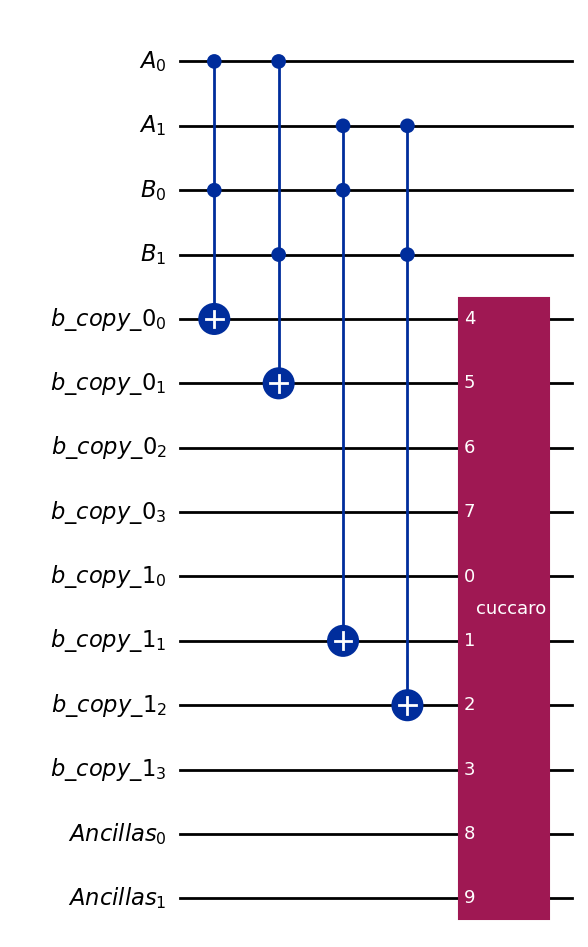

In [3]:
# Build the circuit
# b_0 will hold the final product
from qiskit.synthesis import adder_ripple_c04
n = 2
a = QuantumRegister(n, name="A")
b = QuantumRegister(n, name="B")
b_copies = [QuantumRegister(n*2, name=f"b_copy_{i}") for i in range(n)]
anc  = QuantumRegister(2, name="Ancillas")  # For the half adder

mult_qc = QuantumCircuit(a, b, *b_copies, anc)

# Copy b n times and shift each copy
for i in range(n):
    for j in range(n):
        mult_qc.ccx(a[i], b[j], b_copies[i][j+i])
        # Also shift while we're at it
        # Also AND with A while we're at it

# Add the shifted copies together
cuccaro_qc = adder_ripple_c04(n*2)
cuccaro_qc.name = "cuccaro"
mult_qc.append(cuccaro_qc, list(b_copies[1]) + list(b_copies[0]) + list(anc))

mult_qc.draw(output="mpl")

## Test

Size: 29
Toffoli count: 12
CZ count: 212
T count: 84
Depth: 23
Toffoli depth: 9
CZ depth: 155
T depth: 36
Width: 14
Algebraic connectivity: 0.3985521955550824


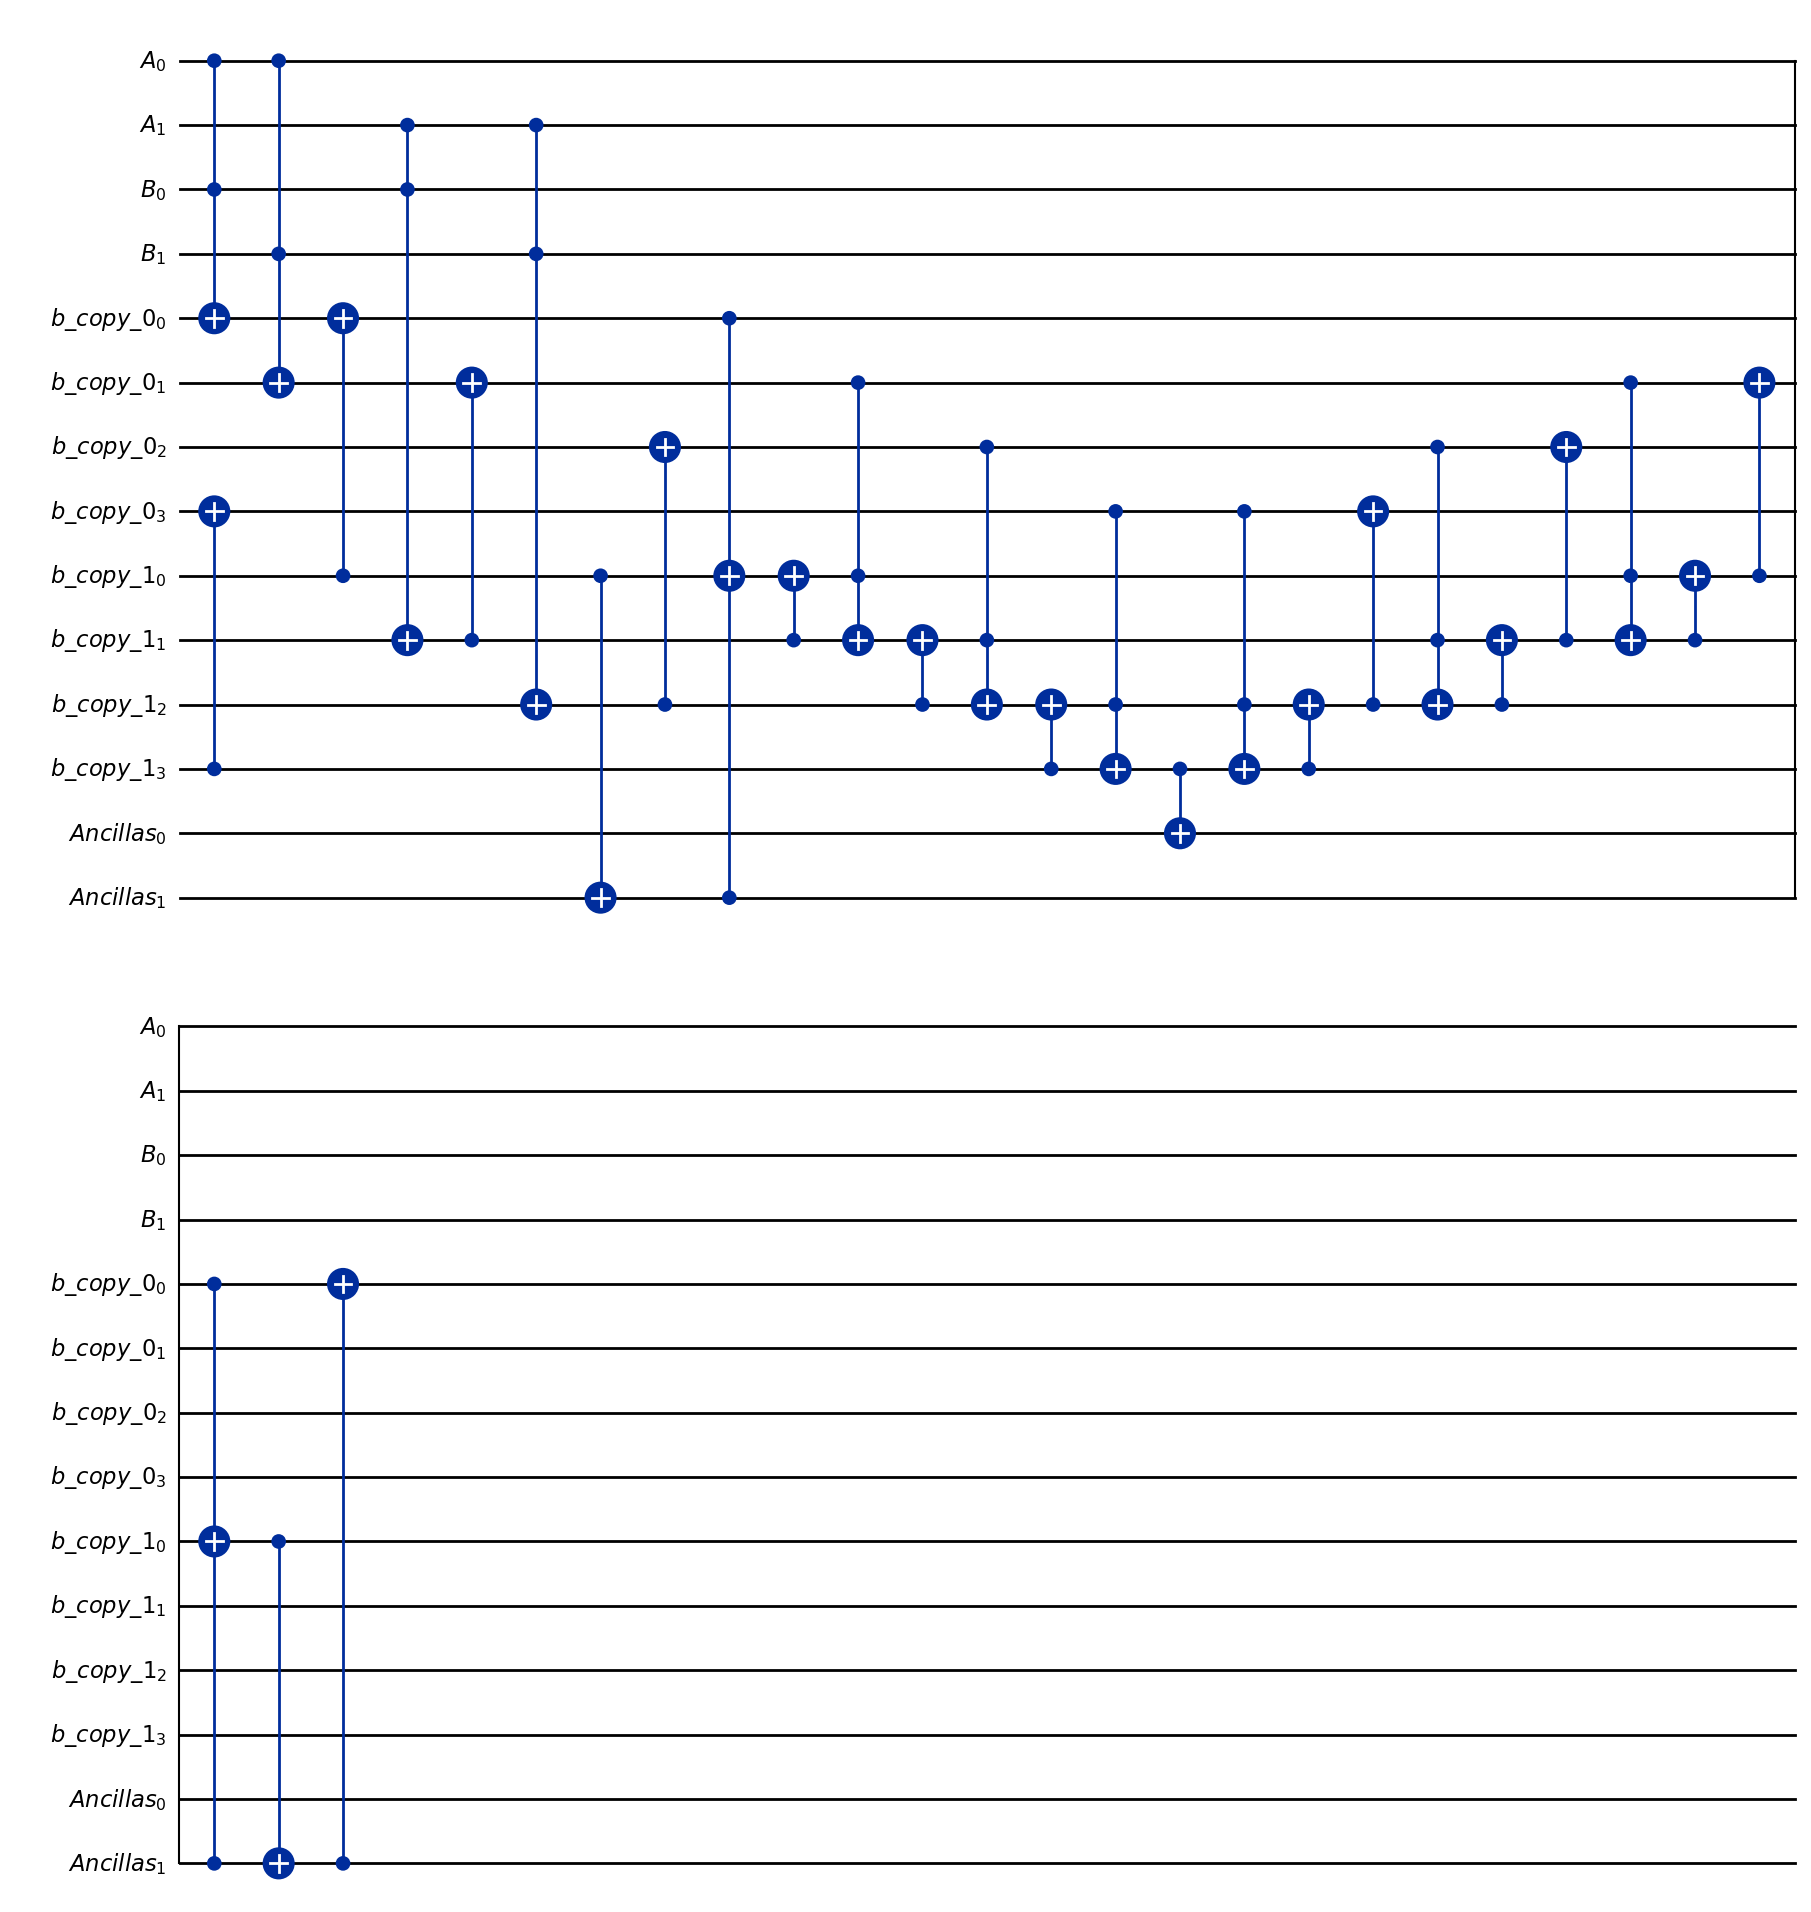

In [11]:
expanded = mult_qc.decompose(gates_to_decompose=[cuccaro_qc.name, "MAJ", "UMA"], reps=2)
print_metrics(expanded)
expanded.draw(output="mpl")

In [12]:
# Test multiplier
start_first_copy = 2 + (2*n)*(n-1)
test_circuit(
    mult_qc,
    list(range(2**n)), a,
    list(range(2**n)), b,
    [a, b] + b_copies + [anc],
    lambda a, b: a * b,
    (start_first_copy, start_first_copy + 2*n)
)

Initial state: 00000000000000
Final state:   00000000000000
Initial state: 00000000000100
Final state:   00000000000100
Initial state: 00000000001000
Final state:   00000000001000
Initial state: 00000000001100
Final state:   00000000001100
Initial state: 00000000000001
Final state:   00000000000001
Initial state: 00000000000101
Final state:   00000000010101
Initial state: 00000000001001
Final state:   00000000101001
Initial state: 00000000001101
Final state:   00000000111101
Initial state: 00000000000010
Final state:   00000000000010
Initial state: 00000000000110
Final state:   00001000100110
Initial state: 00000000001010
Final state:   00010001001010
Initial state: 00000000001110
Final state:   00011001101110
Initial state: 00000000000011
Final state:   00000000000011
Initial state: 00000000000111
Final state:   00001000110111
Initial state: 00000000001011
Final state:   00010001101011
Initial state: 00000000001111
Final state:   00011010011111
Total wrongs: 0
Total tests: 16


## Run

00 • 00 = 0000

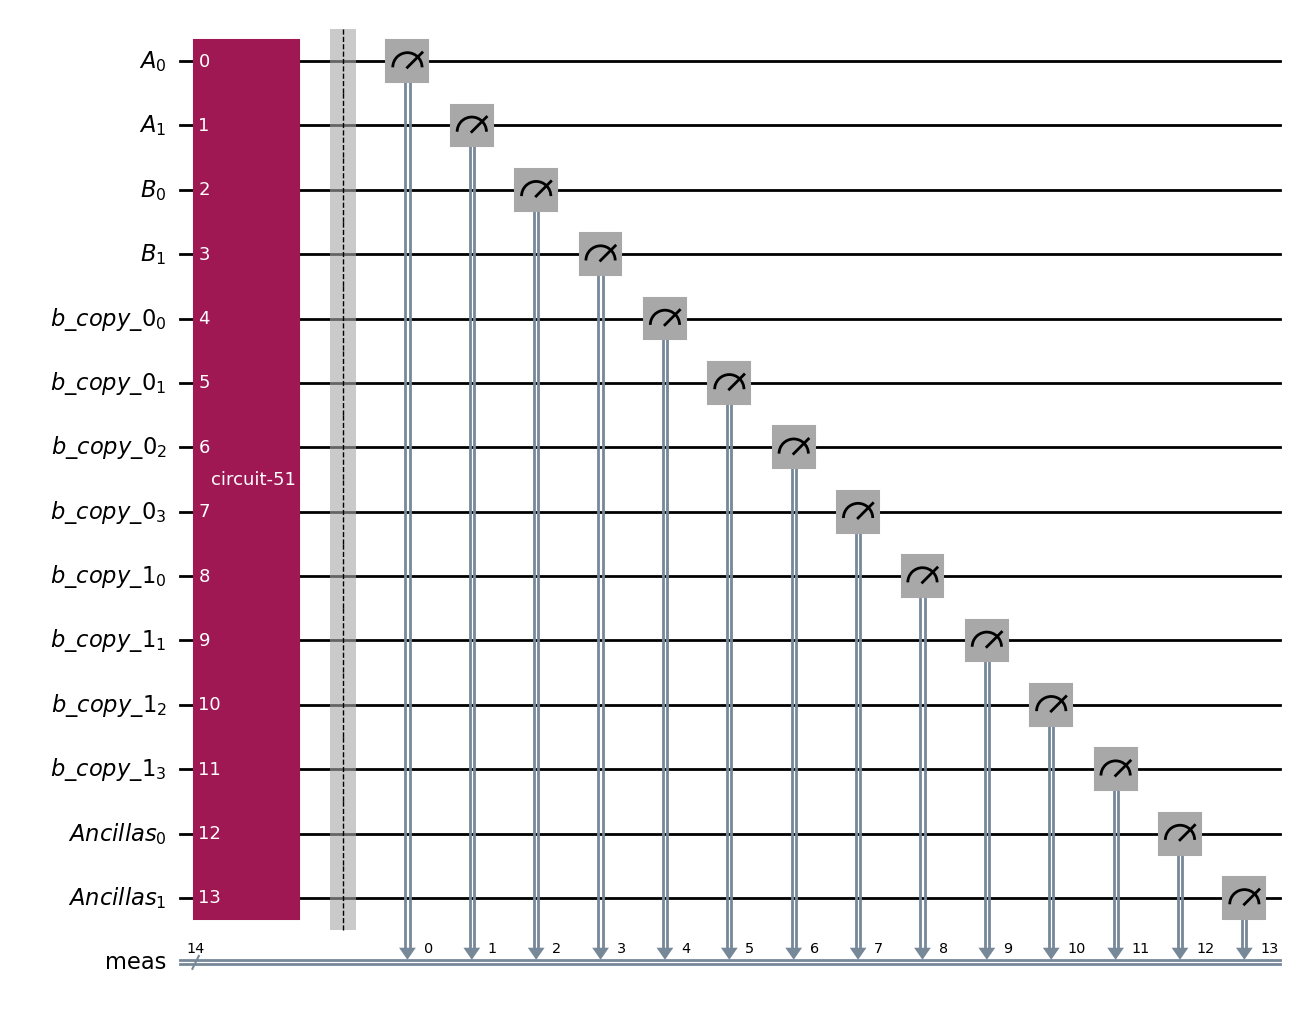

In [14]:
test_0 = QuantumCircuit(a, b, *b_copies, anc)
test_0.append(mult_qc, [*a, *b, *b_copies[0], *b_copies[1], *anc])
test_0.measure_active()
test_0.draw(output="mpl")

In [ ]:
backend_sampler.options.default_shots = 2**11
isa_circuit_mult_qiskit = pm.run(test_0)
job = backend_sampler.run([isa_circuit_mult_qiskit])
print(f"Job ID: {job.job_id()}")

>>> Job ID: d9ai6fjv6alc73crqti0


Top 10 results:
{'00000000000000': 600, '00000000100000': 133, '00000001000000': 131, '01000000000000': 91, '00000000010000': 61, '00000010000000': 49, '00000000001000': 44, '01000001000000': 30, '00000001100000': 29, '01000000100000': 23}
Number of keys: 394
Number of shots: 2048
Expected result 00000000000000: 600
Probability: 0.2930


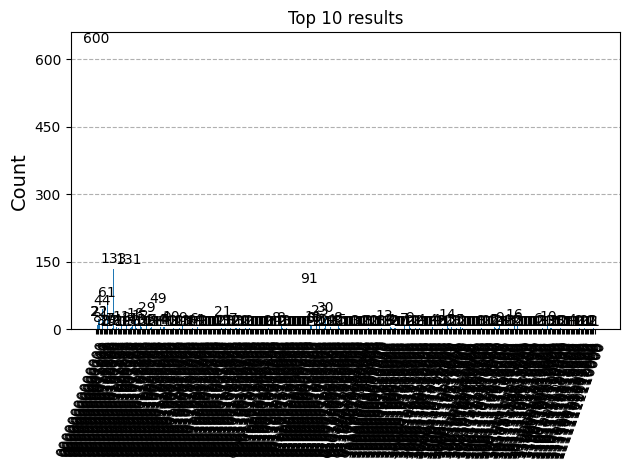

In [ ]:
inspect_results(job, "00000000000000")

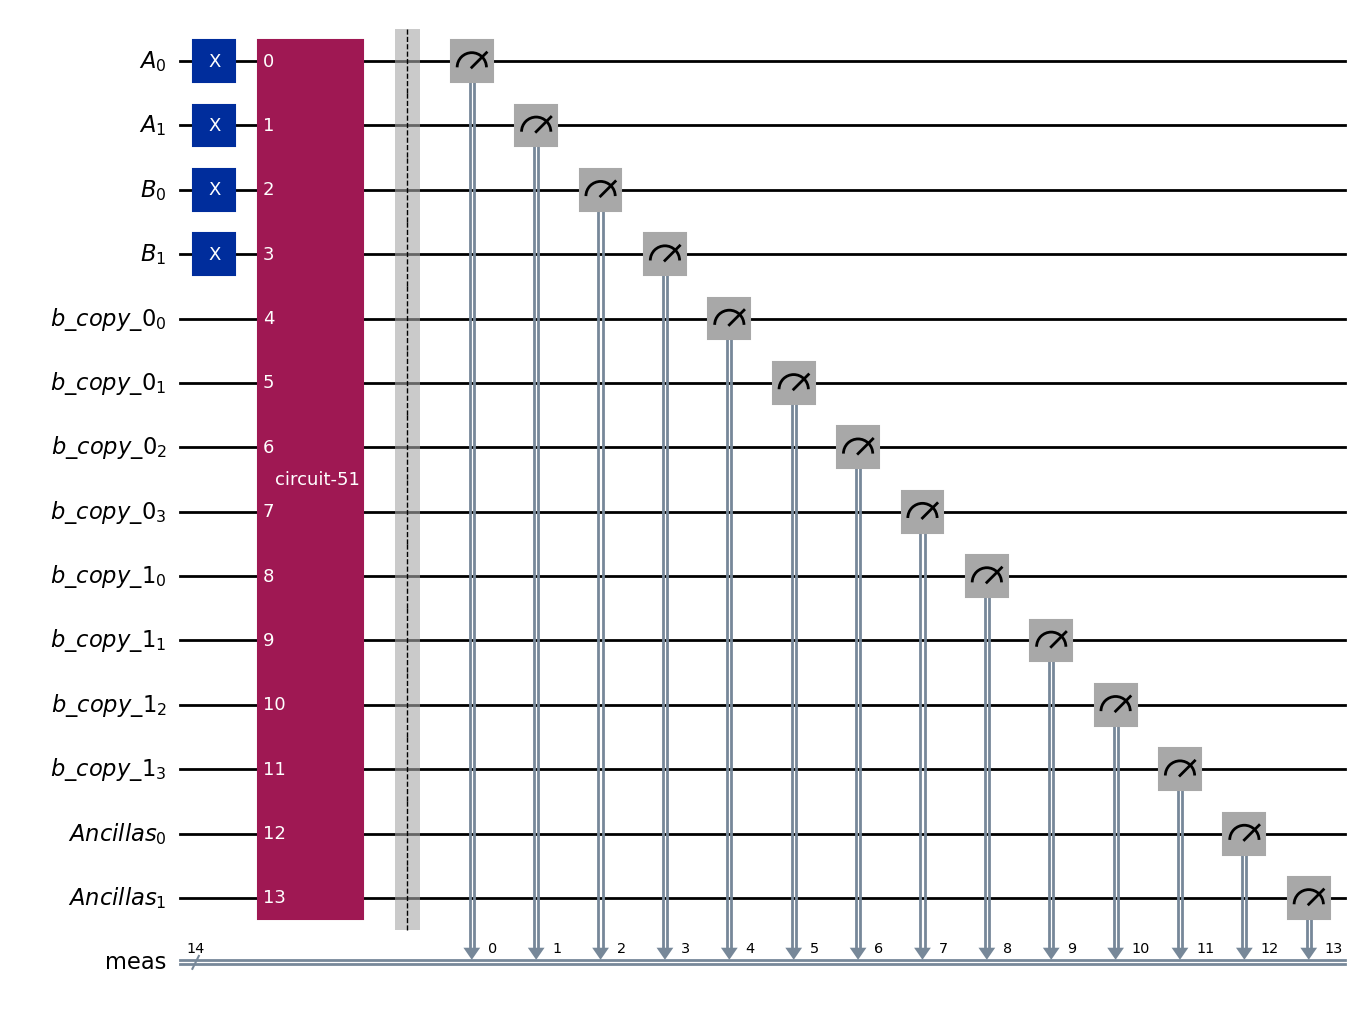

In [21]:
test_1 = QuantumCircuit(a, b, *b_copies, anc)
for i in range(n):
    test_1.x(a[i])
    test_1.x(b[i])
test_1.append(mult_qc, [*a, *b, *b_copies[0], *b_copies[1], *anc])
test_1.measure_active()
test_1.draw(output="mpl")

In [22]:
isa_circuit_mult_qiskit = pm.run(test_1)
job_1 = backend_sampler.run([isa_circuit_mult_qiskit])
print(f"Job ID: {job.job_id()}")

Job ID: d9ai6fjv6alc73crqti0


Top 10 results:
{'00011010011111': 628, '00011010111111': 118, '00011010011011': 117, '01011010011111': 101, '00011010011101': 98, '00011011011111': 85, '00011010001111': 80, '00011010011110': 70, '00011010010111': 57, '00011000011111': 54}
Number of keys: 1196
Number of shots: 4096
Expected result 00011010011111: 628
Probability: 0.1533


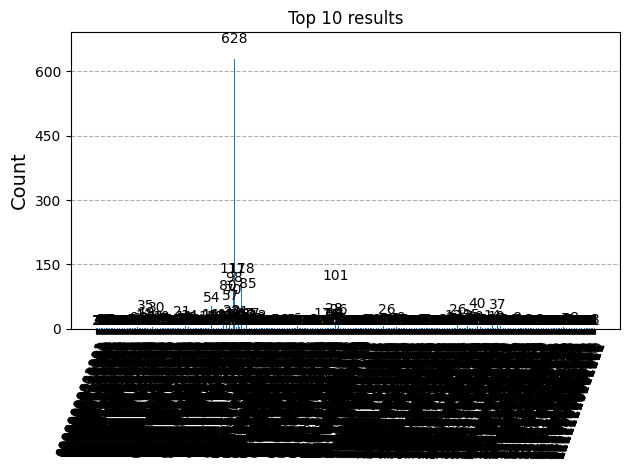

In [23]:
inspect_results(job_1, "00011010011111")